In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel(
    "Missing SKU.xlsx",
    sheet_name="Sheet1"
)

print(df.shape)
df.head()

(329561, 5)


,STORE ID,DATE OF AUDIT,CATEGORY,SKU NAME,BARCODE
0,6437,2017-07-21,Oral_口腔护理,佳洁士3D钻亮炫白牙膏116克,37000889427
1,35476,2017-07-22,Oral_口腔护理,佳洁士3D钻亮炫白牙膏116克,37000889427
2,32911,2017-07-23,Oral_口腔护理,佳洁士3D钻亮炫白牙膏116克,37000889427
3,7850,2017-07-23,Oral_口腔护理,佳洁士3D钻亮炫白牙膏116克,37000889427
4,6653,2017-07-24,Oral_口腔护理,佳洁士3D钻亮炫白牙膏116克,37000889427


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 329561 entries, 0 to 329560
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   STORE ID       329561 non-null  int64         
 1   DATE OF AUDIT  329561 non-null  datetime64[ns]
 2   CATEGORY       329561 non-null  object        
 3   SKU NAME       329561 non-null  object        
 4   BARCODE        329561 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 12.6+ MB


In [3]:
df.describe()

,STORE ID,DATE OF AUDIT,BARCODE
count,329561.000000,329561,3.295610e+05
mean,18468.659541,2017-07-13 03:16:42.493620224,6.809156e+12
min,2.000000,2017-07-01 00:00:00,3.700089e+10
25%,4730.000000,2017-07-06 00:00:00,6.903148e+12
50%,12081.000000,2017-07-11 00:00:00,6.903148e+12
75%,33618.000000,2017-07-20 00:00:00,6.903148e+12
max,40689.000000,2017-07-31 00:00:00,1.690315e+13
std,14322.581950,NaN,8.365486e+11


In [4]:
missing = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

print(missing)

STORE ID         0
DATE OF AUDIT    0
CATEGORY         0
SKU NAME         0
BARCODE          0
dtype: int64


In [5]:
print(
"Duplicate rows:",
df.duplicated().sum()
)

Duplicate rows: 0


In [6]:
for col in df.columns:

    print(
        col,
        "→",
        df[col].nunique()
    )

STORE ID → 3420
DATE OF AUDIT → 31
CATEGORY → 8
SKU NAME → 436
BARCODE → 436


In [7]:
#Uniqueness
key = [
"STORE ID",
"SKU NAME",
"DATE OF AUDIT"
]

print(
df[key]
.drop_duplicates()
.shape[0]
)

print(
len(df)
)

329561
329561


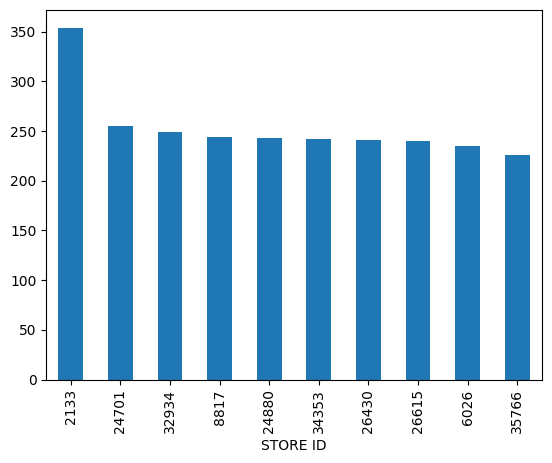

In [8]:
# Top Stores

(
df["STORE ID"]
.value_counts()
.head(10)
.plot(
kind="bar"
)
)

plt.show()

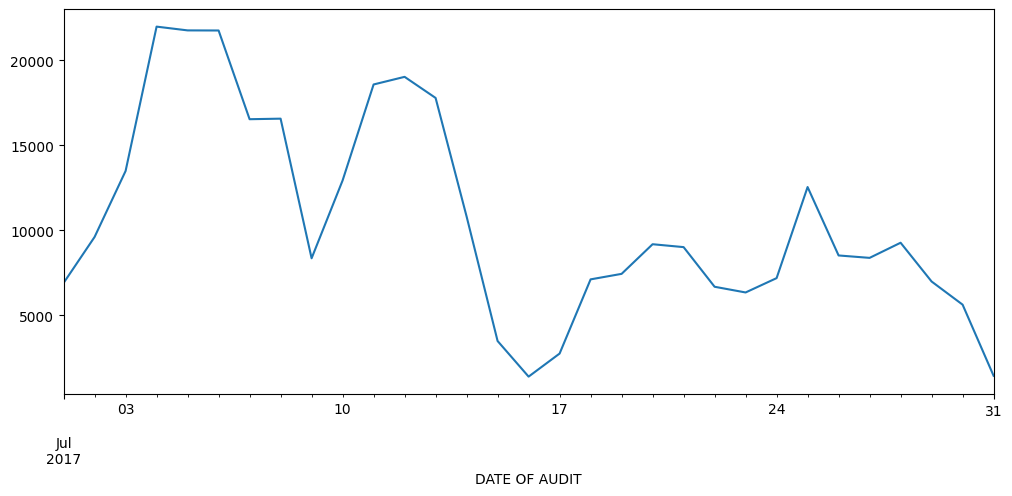

In [9]:
# Analyse Trends

df["DATE OF AUDIT"] = pd.to_datetime(
    df["DATE OF AUDIT"]
)

daily = (
df.groupby(
"DATE OF AUDIT"
)
.size()
)

daily.plot(
figsize=(12,5)
)

plt.show()

C:\Users\vinyt\tfenv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27927 (\N{CJK UNIFIED IDEOGRAPH-6D17}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\vinyt\tfenv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25252 (\N{CJK UNIFIED IDEOGRAPH-62A4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\vinyt\tfenv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21457 (\N{CJK UNIFIED IDEOGRAPH-53D1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\vinyt\tfenv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21475 (\N{CJK UNIFIED IDEOGRAPH-53E3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\vinyt\tfenv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 33108 (\N{CJK UNIFIED IDEOGRAPH-8154}) missing from font(s) DejaVu Sans.
  fig.canvas.prin

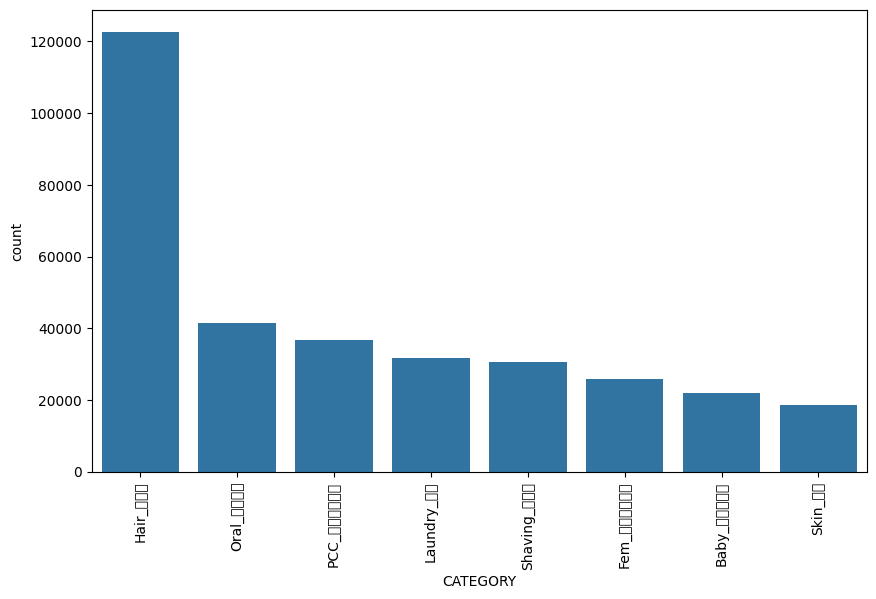

In [10]:
# Category Distribution

plt.figure(figsize=(10,6))

sns.countplot(
x="CATEGORY",
data=df,
order=df["CATEGORY"]
.value_counts()
.index
)

plt.xticks(rotation=90)

plt.show()